In [22]:
import re
import nltk
import pandas as pd
import numpy as np
from nltk import PorterStemmer
from nltk.corpus import stopwords
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import recall_score,precision_score,f1_score,confusion_matrix
from sklearn.svm import LinearSVC
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression,SGDClassifier
from sklearn.ensemble import RandomForestClassifier,BaggingClassifier,AdaBoostClassifier
import joblib
data=pd.read_csv('data/spam mail.csv')

Preprossing

In [23]:
data['Category']=LabelEncoder().fit_transform(data['Category'])
data['Masseges'].rename('Messages',inplace=True)
data['num_char']=data['Masseges'].apply(len)
data['num_words']=data['Masseges'].apply(lambda x: len(x.split()))
data['num_sentences']=data['Masseges'].apply(lambda x: len(x.split('.')))
nltk.download('stopwords')
nltk.download('punkt')
ps =PorterStemmer()
stop_words = set(stopwords.words('english'))
def preprocess(text):
    # 1. Lowercase
    text = text.lower()
    # 2. Remove special characters
    text = re.sub(r'[^a-z\s]', '', text)
    # 3. Tokenization
    tokens = text.split()
    # 4. Remove stop words & punctuation
    tokens = [word for word in tokens if word not in stop_words]
    # 5. Stemming
    tokens = [ps.stem(word) for word in tokens]
    return ' '.join(tokens)

data['Masseges'] = data['Masseges'].apply(preprocess)
data.head()

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/manoj_s/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /home/manoj_s/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


,Category,Masseges,num_char,num_words,num_sentences
0,0,go jurong point crazi avail bugi n great world...,111,20,9
1,0,ok lar joke wif u oni,29,6,7
2,1,free entri wkli comp win fa cup final tkt st m...,155,28,2
3,0,u dun say earli hor u c alreadi say,49,11,7
4,0,nah dont think goe usf live around though,61,13,1


Splitting data into train, validation and test sets

In [24]:
train_data,test_data=train_test_split(data,test_size=0.2,random_state=42)
train_data,vali_data=train_test_split(train_data,test_size=0.2,random_state=42)

Seperating messages and category columns

In [25]:
train_X,train_y=train_data['Masseges'],train_data['Category']
test_X,test_y=test_data['Masseges'],test_data['Category']
vali_X,vali_y=vali_data['Masseges'],vali_data['Category']

In [26]:
vectorizer=TfidfVectorizer()
train_X_vectorized=vectorizer.fit_transform(train_X)
test_X_vectorized=vectorizer.transform(test_X)
vali_X_vectorized=vectorizer.transform(vali_X)

Modeling the data

In [27]:
def classify(model):
    model.fit(train_X_vectorized,train_y)
    pred=model.predict(vali_X_vectorized)
    print(f"Confusion matrix: \n{confusion_matrix(vali_y,pred)}")
    print("Precision:",precision_score(vali_y,pred))
    print("Recall:",recall_score(vali_y,pred))
    print("F1 score:",f1_score(vali_y,pred))

In [28]:
dt= DecisionTreeClassifier()
lr= LogisticRegression()
rf= RandomForestClassifier(n_estimators=50, random_state=42)
dummy= DummyClassifier()
svc= LinearSVC()
ad=AdaBoostClassifier(n_estimators=50, random_state=42)
knn= KNeighborsClassifier()
bg=BaggingClassifier(n_estimators=100,random_state=42) 

models={
    'DecisionTree': dt,
    'LogisticReg': lr,
    'RandomForest': rf,
    'Dummy': dummy,
    'SVC': svc,
    'KNN': knn,
    'AdaBoost': ad,
    'Bagging': bg
}

In [29]:
for name, model in models.items():
    print(f"Name:{name}:\n{classify(model)}")

Confusion matrix: 
[[761  33]
 [ 24  74]]
Precision: 0.6915887850467289
Recall: 0.7551020408163265
F1 score: 0.7219512195121951
Name:DecisionTree:
None
Confusion matrix: 
[[792   2]
 [ 32  66]]
Precision: 0.9705882352941176
Recall: 0.673469387755102
F1 score: 0.7951807228915663
Name:LogisticReg:
None
Confusion matrix: 
[[793   1]
 [ 25  73]]
Precision: 0.9864864864864865
Recall: 0.7448979591836735
F1 score: 0.8488372093023255
Name:RandomForest:
None
Confusion matrix: 
[[794   0]
 [ 98   0]]
Precision: 0.0
Recall: 0.0
F1 score: 0.0
Name:Dummy:
None
Confusion matrix: 
[[790   4]
 [ 16  82]]
Precision: 0.9534883720930233
Recall: 0.8367346938775511
F1 score: 0.8913043478260869
Name:SVC:
None
Confusion matrix: 
[[794   0]
 [ 70  28]]
Precision: 1.0
Recall: 0.2857142857142857
F1 score: 0.4444444444444444
Name:KNN:
None


/home/manoj_s/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Confusion matrix: 
[[781  13]
 [ 41  57]]
Precision: 0.8142857142857143
Recall: 0.5816326530612245
F1 score: 0.6785714285714286
Name:AdaBoost:
None
Confusion matrix: 
[[781  13]
 [ 18  80]]
Precision: 0.8602150537634409
Recall: 0.8163265306122449
F1 score: 0.837696335078534
Name:Bagging:
None


In [30]:
result=pd.DataFrame({'Model':list(models.keys()),
    'Precision':[precision_score(test_y,model.predict(test_X_vectorized)) for model in models.values()],
    'Recall':[recall_score(test_y,model.predict(test_X_vectorized)) for model in models.values()],
    'F1 Score':[f1_score(test_y,model.predict(test_X_vectorized)) for model in models.values()]})
result.sort_values(by=['Recall', 'Precision'], ascending=False, inplace=True)
result # Since recall is important in this problem, we will focus on the model with the highest recall.So, 
#    we'll choose the SVC model for our final model.

/home/manoj_s/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,Model,Precision,Recall,F1 Score
4,SVC,0.984733,0.860000,0.918149
2,RandomForest,1.000000,0.820000,0.901099
7,Bagging,0.924812,0.820000,0.869258
0,DecisionTree,0.823129,0.806667,0.814815
1,LogisticReg,0.960784,0.653333,0.777778
6,AdaBoost,0.873786,0.600000,0.711462
5,KNN,1.000000,0.353333,0.522167
3,Dummy,0.000000,0.000000,0.000000


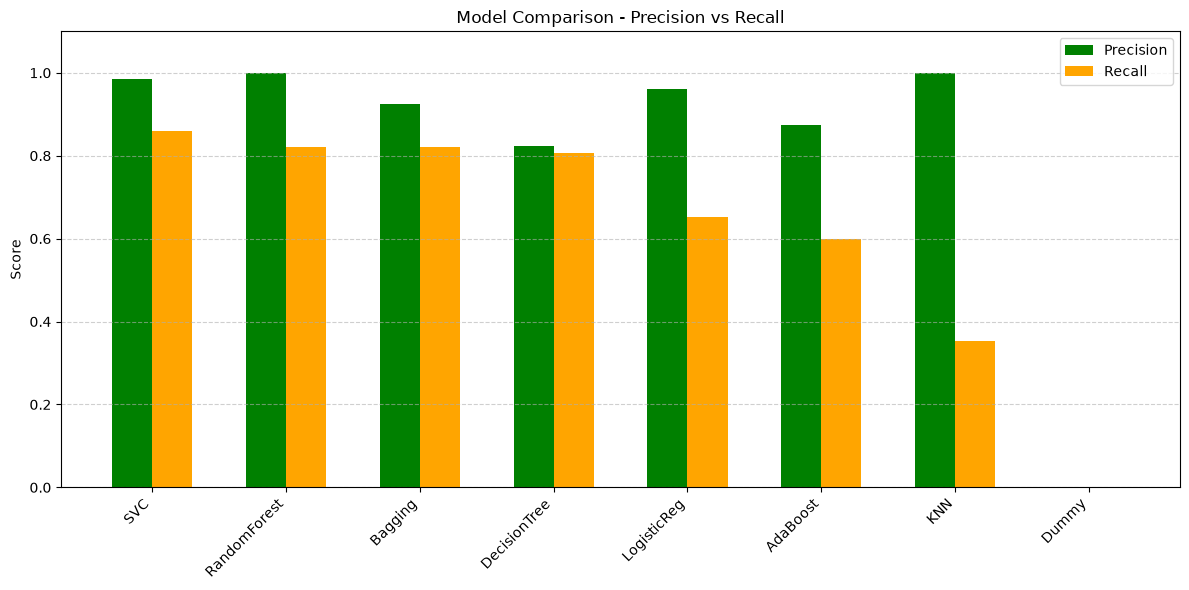

In [31]:
x = np.arange(len(models))
width = 0.3
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width/2, result['Precision'], width, label='Precision', color='green')
ax.bar(x + width/2, result['Recall'],    width, label='Recall',    color='orange')
ax.set_xticks(x)
ax.set_xticklabels(result['Model'], rotation=45, ha='right')
ax.set_ylim(0, 1.1)
ax.set_title('Model Comparison - Precision vs Recall')
ax.set_ylabel('Score')
ax.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("result/Model_comparison.png")
plt.show()

Saving the best model for API using joblib

In [33]:
joblib.dump(svc,"model_file.pkl")
joblib.dump(vectorizer,"vectorizer_file.pkl")

['vectorizer_file.pkl']